In [7]:
# !pip install onnx==1.16.0 onnxruntime==1.16.3 onnxscript
# !pip uninstall -y onnx onnxruntime onnxscript
# https://bitbucket.ap-team.ru/projects/RES/repos/res.models.inference/browse

In [1]:
# !pip uninstall -y onnxruntime onnxruntime-gpu
# !pip install onnx==1.16.0 onnxruntime-gpu==1.17.1 onnxscript
# !apt-get install libcudnn8 libcudnn8-dev # маст хев чтобы работало на гпу

In [3]:
# !pip install efficientnet_pytorch

In [8]:
# from omegaconf import OmegaConf
# from src.model import TransformDecoder, ImageTransformPredictor
# from src.dataset import ImageTransformer, TransformTokenizer, TRANSFORM_TOKENS
# from PIL import Image

# config = OmegaConf.load('configs/train_config_vit.yaml')
# model = ImageTransformPredictor(config.model)

# checkpoint_path = 'checkpoints/itp_vit_tune_full/checkpoint_epoch_35.pth'

# checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
# model.load_state_dict(checkpoint['model_state_dict'])
# model.to('cpu')
# model.eval()
# print('ready')

In [9]:
import torch
import sys
from pathlib import Path

src_path = "../"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

In [10]:
import torch
import torch.nn as nn
from torchvision.models import vit_b_16, ViT_B_16_Weights
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image

In [11]:
preprocess = transforms.Compose([
            transforms.Resize((300, 300)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

#### ImageEncoder

In [154]:
# class ImageEncoder(nn.Module):
#     def __init__(self, out_token_n_embd: int = 512):
#         super().__init__()
#         weights = ViT_B_16_Weights.IMAGENET1K_V1
#         self.vit = vit_b_16(weights=weights)
#         self.vit.heads = nn.Identity()
#         self.feature_dim = self.vit.hidden_dim
#         self.proj = nn.Linear(self.feature_dim, out_token_n_embd)
#         self.patch_size = self.vit.conv_proj.kernel_size[0]
#         self.hidden_dim = self.vit.hidden_dim

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         batch_size = x.shape[0]
#         x = self.vit.conv_proj(x)
#         x = x.flatten(2)
#         x = x.transpose(1, 2)
#         class_token = self.vit.class_token.expand(batch_size, -1, -1)
#         x = torch.cat([class_token, x], dim=1)
#         x = x + self.vit.encoder.pos_embedding
#         x = self.vit.encoder.layers(x)
#         if hasattr(self.vit.encoder, 'ln'):
#             x = self.vit.encoder.ln(x)
#         x = self.proj(x)
#         return x

In [3]:
from model_effnet_torch import ImageEncoder, ImageFuser, TransformationDecoder

In [4]:
encoder = ImageEncoder()
encoder.load_state_dict(torch.load('/mnt/DATA2/dorin/weights/transformpredictor/effnet_based_contrastive_v5/image_encoder.pth'))
encoder.eval()
print('ready')

ready


In [12]:
# import torch

# dummy_input = torch.randn(1, 3, 300, 300, device='cpu')

# torch.onnx.export(
#     encoder,
#     dummy_input,
#     '/mnt/DATA2/dorin/weights/transformpredictor/effnet_based_contrastive_v5/image_encoder.onnx',
#     input_names=["image_input"],
#     output_names=["image_embedding"],
#     opset_version=18,
#     do_constant_folding=True,
#     dynamic_axes={
#         "image_input": {
#             0: "batch_size"
#         },
#         "image_embedding": {
#             0: "batch_size",
#         }
#     },
#     verbose=False
# )

In [7]:
# !pip install numpy==1.26.4

#### how to use onnx

In [9]:
import onnxruntime as ort

In [10]:
ort.get_available_providers()

['AzureExecutionProvider', 'CPUExecutionProvider']

In [11]:
ort.__version__

'1.16.3'

In [13]:
# 1. Указываем провайдеры: сначала GPU (CUDA), потом CPU
providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']

# 2. Передаем providers в сессию
ort_session = ort.InferenceSession(
    '/mnt/DATA2/dorin/weights/transformpredictor/effnet_based_contrastive_v4/image_encoder.onnx',
    providers=providers
)

# Проверка: какие провайдеры активны
print("Активные провайдеры:", ort_session.get_providers())

Активные провайдеры: ['CPUExecutionProvider']


по хорошему нужно экспортировать модель уже на гпу из торча иначе происходит переброс некоторых операций с цпу на гпу

```
2026-02-24 14:56:47.218842072 [W:onnxruntime:, transformer_memcpy.cc:74 ApplyImpl] 12 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.
```

In [15]:
ort_session = ort.InferenceSession('/mnt/DATA2/dorin/weights/transformpredictor/effnet_based_contrastive_v4/image_encoder.onnx',)

inputs = ort_session.get_inputs()
for i in inputs:
    print(f"Input name: {i.name}, shape: {i.shape}, type: {i.type}")

outputs = ort_session.get_outputs()
for o in outputs:
    print(f"Output name: {o.name}, shape: {o.shape}, type: {o.type}")

Input name: image_input, shape: ['batch_size', 3, 300, 300], type: tensor(float)
Output name: image_embedding, shape: ['batch_size', 1536], type: tensor(float)


In [16]:
dummy_input = torch.randn(1, 3, 300, 300, device='cpu')

In [17]:
import numpy as np
outputs = ort_session.run(None, {'image_input': np.array(dummy_input)})

In [18]:
outputs[0].shape

(1, 1536)

In [19]:
dummy_input = torch.randn(1, 3, 300, 300, device='cpu')

In [22]:
# !python -m pip install --force-reinstall -U ap_res_models_inference --index-url https://nexus.ap-team.ru/repository/pypi/simple

from ap_res_models_inference import get_model
import numpy as np

model = get_model(
    engine_name= 'onnx',
    path_to_weights='/mnt/DATA2/dorin/weights/transformpredictor/effnet_based_contrastive_v5/image_encoder.onnx',
    use_gpu=0
)

outputs = model(image_input=np.array(dummy_input)) # image_input нейминг как при экспорте
outputs.shape

(1, 1536)

In [23]:
onnx_model = model.model
onnx_model.get_providers()

['CPUExecutionProvider']

#### decoder and fuser

In [24]:
# class ImageFuser(nn.Module):
#     def __init__(self, embed_dim: int = 512):
#         super().__init__()
#         self.embed_dim = embed_dim
#         self.sep_token = nn.Parameter(torch.randn(1, 1, embed_dim))

#     def forward(self, embs1: torch.Tensor, embs2: torch.Tensor) -> torch.Tensor:
#         B = embs1.shape[0]
#         sep = self.sep_token.expand(B, -1, -1)
#         return torch.cat([embs1, sep, embs2], dim=1)


# # =============================================================================
# # DecoderBlock:
# # =============================================================================

# class DecoderBlock(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.ln_1 = nn.LayerNorm(512, elementwise_affine=False)
#         self.ln_2 = nn.LayerNorm(512, elementwise_affine=False)
#         self.ln_3 = nn.LayerNorm(512, elementwise_affine=False)

#         self.attn = nn.MultiheadAttention(
#             embed_dim=512,
#             num_heads=8,
#             dropout=0.1,
#             bias=False,
#             batch_first=True,
#         )

#         self.cross_attn = nn.MultiheadAttention(
#             embed_dim=512,
#             num_heads=8,
#             dropout=0.1,
#             bias=False,
#             batch_first=True,
#         )

#         self.net = nn.Sequential(
#             nn.Linear(512, 2048, bias=False),
#             nn.GELU(),
#             nn.Linear(2048, 512, bias=False),
#         )
#         self.dropout_layer = nn.Dropout(0.1)

#         mask = torch.triu(torch.full((15, 15), float('-inf')), diagonal=1)
#         self.register_buffer("future_mask", mask, persistent=False)

#     def forward(self, x: torch.Tensor, images_embeddings: torch.Tensor) -> torch.Tensor:
#         _, T, _ = x.shape
#         attn_mask = self.future_mask[:T, :T].to(x.device)
#         x = x + self.attn(
#             query=self.ln_1(x),
#             key=self.ln_1(x),
#             value=self.ln_1(x),
#             attn_mask=attn_mask,
#             need_weights=False
#         )[0]

#         x = x + self.cross_attn(
#             query=self.ln_2(x),
#             key=images_embeddings,
#             value=images_embeddings,
#             need_weights=False
#         )[0]

#         x = x + self.dropout_layer(self.net(self.ln_3(x)))
#         return x


# # =============================================================================
# # TransformationDecoder
# # =============================================================================

# class TransformationDecoder(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.n_embd = 512
#         self.n_head = 8
#         self.n_layer = 3
#         self.max_seq_len = 15
#         self.vocab_size = 14
#         self.dropout = 0.1
#         self.bias = False
#         self.bos_token_id = 1
#         self.eos_token_id = 2
#         self.pad_token_id = 0

#         self.token_embedding = nn.Embedding(self.vocab_size, self.n_embd)
#         self.position_embedding = nn.Embedding(self.max_seq_len, self.n_embd)
#         self.blocks = nn.ModuleList([DecoderBlock() for _ in range(self.n_layer)])
#         self.ln_f = nn.LayerNorm(self.n_embd, elementwise_affine=self.bias)
#         self.lm_head = nn.Linear(self.n_embd, self.vocab_size, bias=False)

#     def forward(self, images_embeddings: torch.Tensor, idx: torch.Tensor) -> torch.Tensor:
#         _, T = idx.shape
#         tok_emb = self.token_embedding(idx)
#         pos = torch.arange(T, device=idx.device)
#         pos_emb = self.position_embedding(pos)
#         x = tok_emb + pos_emb

#         for block in self.blocks:
#             x = block(x, images_embeddings)
#         x = self.ln_f(x)
#         logits = self.lm_head(x)
#         return logits[:, -1, :]

#     @torch.no_grad()
#     def generate(
#         self,
#         images_embeddings: torch.Tensor,
#         max_new_tokens: int = 10,
#         temperature: float = 1.0,
#         do_sample: bool = False,
#     ) -> torch.Tensor:
#         B = images_embeddings.shape[0]
#         device = images_embeddings.device
#         total_len = 1 + max_new_tokens
#         assert total_len <= self.max_seq_len

#         idx = torch.full((B, 1), self.bos_token_id, dtype=torch.long, device=device)
#         finished = torch.zeros(B, dtype=torch.bool, device=device)

#         for _ in range(max_new_tokens):
#             logits = self(images_embeddings, idx)
#             next_logits = logits / temperature
#             next_logits[:, self.pad_token_id] = -float('inf')
#             next_logits[:, self.bos_token_id] = -float('inf')

#             if do_sample:
#                 probs = F.softmax(next_logits, dim=-1)
#                 idx_next = torch.multinomial(probs, num_samples=1).squeeze(-1)
#             else:
#                 idx_next = torch.argmax(next_logits, dim=-1)

#             newly_finished = (idx_next == self.eos_token_id)
#             finished = finished | newly_finished
#             idx = torch.cat([idx, idx_next.unsqueeze(-1)], dim=1)

#             if finished.all():
#                 break

#         if idx.size(1) < total_len:
#             pad = torch.full(
#                 (B, total_len - idx.size(1)),
#                 self.pad_token_id,
#                 device=device,
#                 dtype=torch.long
#             )
#             idx = torch.cat([idx, pad], dim=1)
#         else:
#             idx = idx[:, :total_len]

#         for i in range(B):
#             eos_pos = (idx[i] == self.eos_token_id).nonzero(as_tuple=True)[0]
#             if eos_pos.numel() > 0:
#                 idx[i, eos_pos[0].item() + 1:] = self.pad_token_id

#         return idx

In [13]:
fuser = ImageFuser()
fuser.load_state_dict(torch.load('/mnt/DATA2/dorin/weights/transformpredictor/effnet_based_contrastive_v5/fuser.pth'))
fuser.eval()
print('ready')

ready


In [14]:
dummy_source = torch.randn(1, 1536, device='cpu')
dummy_query = torch.randn(1, 1536, device='cpu')

torch.onnx.export(
        fuser,
        (dummy_source, dummy_query),
        '/mnt/DATA2/dorin/weights/transformpredictor/effnet_based_contrastive_v5/fuser.onnx',
        input_names=["source_embedding", "query_embedding"],
        output_names=["fused_context"],
        opset_version=18,
        do_constant_folding=True,
        dynamic_axes={
            "source_embedding": {0: "batch_size"},
            "query_embedding": {0: "batch_size"},
            "fused_context": {0: "batch_size"}
        },
        verbose=False
    )

In [15]:
decoder = TransformationDecoder()
decoder.load_state_dict(torch.load('/mnt/DATA2/dorin/weights/transformpredictor/effnet_based_contrastive_v5/decoder.pth'))
decoder.eval()
print('ready')

ready


In [16]:
import os

dummy_context = torch.randn(
    1,
    1,
    512,
    device='cpu',
    dtype=torch.float32,
    requires_grad=False
)

dummy_tokens = torch.full(
    (1, 1),
    fill_value=1,  # bos_token_id
    device='cpu',
    dtype=torch.long  # критично: Embedding ожидает int64
)

torch.onnx.export(
    decoder,
    (dummy_context, dummy_tokens),  # context: [B, L, D], tokens: [B, T]
    "/mnt/DATA2/dorin/weights/transformpredictor/effnet_based_contrastive_v5/decoder_step.onnx",
    input_names=["context_embedding", "token_ids"],
    output_names=["next_logits"],
    opset_version=18,
    do_constant_folding=True,
    dynamic_axes={
        "context_embedding": {0: "batch_size", 1: "context_len"},
        "token_ids": {0: "batch_size", 1: "seq_len"},
        "next_logits": {0: "batch_size"}
    },
    verbose=False
)

['vertical_flip', 'crop', 'rotate_90']


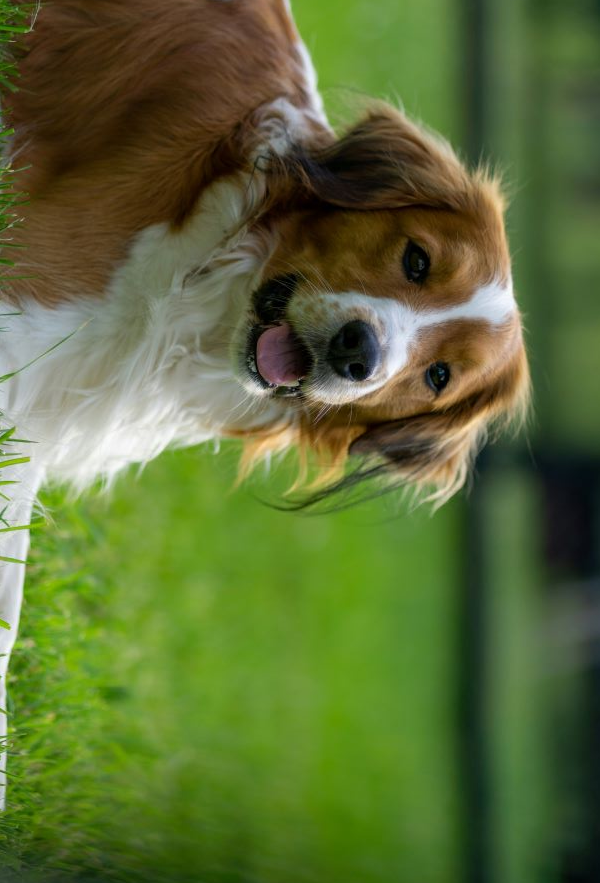

In [13]:
image_path = '../assets/image.jpg'
image = Image.open(image_path)

it = ImageTransformer()
transformed_image, sequence = it.transform(image, p=0.3)
print(sequence)
transformed_image

In [14]:
image_tensor = preprocess(image).unsqueeze(0).repeat(3, 1, 1, 1)
transformed_image_tensor = preprocess(transformed_image).unsqueeze(0).repeat(3, 1, 1, 1)

In [15]:
tokenizer = TransformTokenizer()

In [16]:
image_embs, transformed_image_embs = encoder(image_tensor), encoder(transformed_image_tensor)

In [17]:
image_embs.shape

torch.Size([3, 1536])

In [18]:
images_embeddings = fuser(image_embs, transformed_image_embs)

In [19]:
generated = decoder.generate(images_embeddings, max_new_tokens=10, do_sample=False) #, top_k=3)

tokenizer = TransformTokenizer()
tokens = tokenizer.decode(generated[0], skip_special_tokens=True)
print(f"Predicted: {tokens}")
print(f"Target: {sequence}")

Predicted: ['crop', 'rotate_270', 'vertical_flip']
Target: ['vertical_flip', 'crop', 'rotate_90']


In [20]:
generated

tensor([[ 1, 10,  7, 12,  2,  0,  0,  0,  0,  0,  0],
        [ 1, 10,  7, 12,  2,  0,  0,  0,  0,  0,  0],
        [ 1, 10,  7, 12,  2,  0,  0,  0,  0,  0,  0]])

#### Onnx pipeline

In [22]:
import onnxruntime as ort
import numpy as np
import torch
from PIL import Image
import torchvision.transforms as T

In [23]:
model_dir = "/mnt/DATA2/dorin/weights/transformpredictor/effnet_based_contrastive_v4"

encoder_sess = ort.InferenceSession(
    f"{model_dir}/image_encoder.onnx",
    providers=["CPUExecutionProvider"]
)
fuser_sess = ort.InferenceSession(
    f"{model_dir}/fuser.onnx",
    providers=["CPUExecutionProvider"]
)
decoder_sess = ort.InferenceSession(
    f"{model_dir}/decoder_step.onnx",
    providers=["CPUExecutionProvider"]
)

In [31]:
inputs = encoder_sess.get_inputs()
for i in inputs:
    print(f"Input name: {i.name}, shape: {i.shape}, type: {i.type}")

outputs = encoder_sess.get_outputs()
for o in outputs:
    print(f"Output name: {o.name}, shape: {o.shape}, type: {o.type}")

Input name: image_input, shape: ['batch_size', 3, 300, 300], type: tensor(float)
Output name: image_embedding, shape: ['batch_size', 1536], type: tensor(float)


In [32]:
inputs = fuser_sess.get_inputs()
for i in inputs:
    print(f"Input name: {i.name}, shape: {i.shape}, type: {i.type}")

outputs = fuser_sess.get_outputs()
for o in outputs:
    print(f"Output name: {o.name}, shape: {o.shape}, type: {o.type}")

Input name: source_embedding, shape: ['batch_size', 1536], type: tensor(float)
Input name: query_embedding, shape: ['batch_size', 1536], type: tensor(float)
Output name: fused_context, shape: ['batch_size', 1, 512], type: tensor(float)


In [33]:
inputs = decoder_sess.get_inputs()
for i in inputs:
    print(f"Input name: {i.name}, shape: {i.shape}, type: {i.type}")

outputs = decoder_sess.get_outputs()
for o in outputs:
    print(f"Output name: {o.name}, shape: {o.shape}, type: {o.type}")

Input name: context_embedding, shape: ['batch_size', 'context_len', 512], type: tensor(float)
Input name: token_ids, shape: ['batch_size', 'seq_len'], type: tensor(int64)
Output name: next_logits, shape: ['batch_size', 13], type: tensor(float)


In [52]:
# Параметры
VOCAB_SIZE = 13
BOS_TOKEN_ID = 1
EOS_TOKEN_ID = 2
PAD_TOKEN_ID = 0
MAX_NEW_TOKENS = 10

# Препроцессинг изображений
transform = transforms.Compose([
            transforms.Resize((300, 300)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

# =============================================================================
# 2. Загрузка и кодирование изображений
# =============================================================================

image_path_1 = '../assets/image.jpg'
image_path_2 = '../assets/dog.jpg'

image_1 = Image.open(image_path_1).convert("RGB")
# image_2 = Image.open(image_path_2).convert("RGB")
it = ImageTransformer()
image_2, target = it.transform(image_1, p=0.3)

print(f"Image 1: {image_1.size}")
print(f"Image 2: {image_2.size}")

# Энкодинг
input_1 = transform(image_1).unsqueeze(0).numpy().astype(np.float32)
input_2 = transform(image_2).unsqueeze(0).numpy().astype(np.float32)

embs_1 = encoder_sess.run(None, {"image_input": input_1})[0]  # [1, 197, 512]
embs_2 = encoder_sess.run(None, {"image_input": input_2})[0]  # [1, 197, 512]

print(f"Embeddings 1: {embs_1.shape}")
print(f"Embeddings 2: {embs_2.shape}")

# =============================================================================
# 3. Fusion эмбеддингов
# =============================================================================

fused_context = fuser_sess.run(None, {
    "source_embedding": embs_1.astype(np.float32),
    "query_embedding": embs_2.astype(np.float32)
})[0]  # [1, 395, 512]

print(f"Fused context: {fused_context.shape}")

# =============================================================================
# 4. Генерация последовательности (decoder loop)
# =============================================================================

idx = np.full((1, 1), BOS_TOKEN_ID, dtype=np.int64)
finished = np.zeros(1, dtype=bool)

for step in range(MAX_NEW_TOKENS):
    logits = decoder_sess.run(None, {
        "context_embedding": fused_context.astype(np.float32),
        "token_ids": idx
    })[0]  # [1, vocab_size]
    
    # Mask special tokens
    logits[:, [PAD_TOKEN_ID, BOS_TOKEN_ID]] = -float('inf')
    
    # Greedy decoding
    next_token = np.argmax(logits, axis=-1).astype(np.int64)
    
    # Check EOS
    newly_finished = (next_token == EOS_TOKEN_ID)
    finished = finished | newly_finished
    idx = np.concatenate([idx, next_token[:, None]], axis=1)
    
    if finished.all():
        break

# Pad to fixed length
total_len = 1 + MAX_NEW_TOKENS
if idx.shape[1] < total_len:
    pad = np.full((1, total_len - idx.shape[1]), PAD_TOKEN_ID, dtype=np.int64)
    idx = np.concatenate([idx, pad], axis=1)

# Truncate after first EOS
eos_pos = np.where(idx[0] == EOS_TOKEN_ID)[0]
if len(eos_pos) > 0:
    idx[0, eos_pos[0] + 1:] = PAD_TOKEN_ID

print(f"Generated tokens: {idx[0]}")

# =============================================================================
# 5. Декодинг через ваш токенайзер
# =============================================================================

# Конвертируем в torch tensor для совместимости с вашим токенайзером
generated = torch.from_numpy(idx)

tokenizer = TransformTokenizer()
tokens = tokenizer.decode(generated[0], skip_special_tokens=True)

print(f"\n=== Result ===")
print(f"Predicted: {tokens}")
print(f"Target: {target}")

Image 1: (1000, 667)
Image 2: (1000, 667)
Embeddings 1: (1, 1536)
Embeddings 2: (1, 1536)
Fused context: (1, 1, 512)
Generated tokens: [1 3 2 0 0 0 0 0 0 0 0]

=== Result ===
Predicted: ['noop']
Target: ['noop']


In [53]:
idx = np.full((1, 1), BOS_TOKEN_ID, dtype=np.int64)
# idx = np.repeat(idx, 3, 0)

logits = decoder_sess.run(None, {
    "context_embedding": fused_context.astype(np.float32),
    "token_ids": idx
})[0]  # [1, vocab_size]

In [54]:
logits_stable = logits - logits.max(axis=-1, keepdims=True)
probs = np.exp(logits_stable) / np.exp(logits_stable).sum(axis=-1, keepdims=True)
similarity_score_onnx = 1 - probs[:, EOS_TOKEN_ID]

In [55]:
probs

array([[1.8435041e-13, 2.1220060e-13, 1.0611287e-04, 9.9704367e-01,
        7.4827665e-04, 1.5564339e-08, 7.8257051e-07, 1.6029547e-08,
        1.0589593e-03, 7.6635223e-04, 2.7028221e-04, 2.7407939e-06,
        2.7075739e-06]], dtype=float32)

In [56]:
similarity_score_onnx.item()

0.9998939037322998

In [57]:
embs_1 = encoder(torch.tensor(input_1))
embs_2 = encoder(torch.tensor(input_2))

In [58]:
fused = fuser(embs_1, embs_2)

In [59]:
import torch.nn.functional as F

B = fused.shape[0]
idx_tokens = torch.full(
    (B, 1), 
    decoder.bos_token_id, 
    dtype=torch.long, 
)

logits = decoder(fused, idx_tokens)
logits[:, decoder.pad_token_id] = -float('inf')
logits[:, decoder.bos_token_id] = -float('inf')

probs = F.softmax(logits, dim=-1)

p_eos = probs[:, decoder.eos_token_id]
similarities = 1.0 - p_eos
similarities.item()

0.9998939037322998